In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# NLTK'nin Türkçe gereksiz kelimeler sözlüğünü (stopwords) indiriyoruz
nltk.download('stopwords')

try:
    github_raw_link = "https://raw.githubusercontent.com/oguzhanHarman/MetinMadenciligiProje/main/dataset.csv"
    df = pd.read_csv(github_raw_link)
    print("Veri seti başarıyla yüklendi!\n")
except Exception as e:
    github_raw_link_master = "https://raw.githubusercontent.com/oguzhanHarman/MetinMadenciligiProje/master/dataset.csv"
    df = pd.read_csv(github_raw_link_master)
    print("Veri seti başarıyla yüklendi!\n")

# 2. SINIF DAĞILIMI KONTROLÜ
print("--- Sınıf Dağılımı (1: Gerçek, 0: Sahte) ---")
print(df['status'].value_counts())
print("-" * 40)

# 3. METİN TEMİZLEME FONKSİYONU
durak_kelimeler = set(stopwords.words('turkish'))

def metin_temizle(metin):
    # Eğer metin boşsa hata vermemesi için string'e çevir ve küçük harf yap
    metin = str(metin).lower()

    # URL'leri ve Linkleri sil
    metin = re.sub(r'http\S+', '', metin)

    # Sadece harfleri ve sayıları bırak, noktalamaları sil
    metin = re.sub(r'[^a-z0-9çğıöşü\s]', '', metin)

    # Stop-words (ve, bir, ile gibi gereksiz kelimeler) temizliği
    kelimeler = metin.split()
    temiz_kelimeler = [kelime for kelime in kelimeler if kelime not in durak_kelimeler]

    return " ".join(temiz_kelimeler)

# 4. TEMİZLİĞİ VERİYE UYGULA
print("\nMetinler temizleniyor, bu işlem bilgisayarının hızına göre 5-10 saniye sürebilir...\n")
df['temiz_metin'] = df['description'].apply(metin_temizle)

# 5. SONUÇLARI GÖRELİM
print("Temizleme İşlemi Tamamlandı! İlk 3 satırın 'Önce' ve 'Sonra' hali:\n")
print(df[['description', 'temiz_metin']].head(3))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Veri seti başarıyla yüklendi!

--- Sınıf Dağılımı (1: Gerçek, 0: Sahte) ---
status
0    2845
1    2481
Name: count, dtype: int64
----------------------------------------

Metinler temizleniyor, bu işlem bilgisayarının hızına göre 5-10 saniye sürebilir...

Temizleme İşlemi Tamamlandı! İlk 3 satırın 'Önce' ve 'Sonra' hali:

                                         description  \
0  Antalya merkezli 5 ilde gerçekleştirilen yasa ...   
1  Çevre, Şehircilik ve İklim Değişikliği Bakanı ...   
2  İddiaya göre Mithat Paşa, II. Abdülhamit’in ta...   

                                         temiz_metin  
0  antalya merkezli 5 ilde gerçekleştirilen yasa ...  
1  çevre şehircilik iklim değişikliği bakanı mura...  
2  iddiaya göre mithat paşa ii abdülhamitin tahtt...  


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Matematiksel modele (TF-IDF) geçiyoruz
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Senin 'temiz_metin' sütununu sayılara çeviriyoruz
X = vectorizer.fit_transform(df['temiz_metin'])

# 3. Sonucu gör (Kaç haber x Kaç kelime)
print(f"Veri Madenciliği Sonucu: {X.shape[0]} haber, {X.shape[1]} benzersiz kelimeye (özelliğe) dönüştürüldü.")

# En önemli 10 kelimeyi görelim (Modelin neye odaklandığını anlamak için)
feature_names = vectorizer.get_feature_names_out()
print("\nEn ayırt edici bazı kelimeler:", feature_names[1000:1010])

Veri Madenciliği Sonucu: 5326 haber, 5000 benzersiz kelimeye (özelliğe) dönüştürüldü.

En ayırt edici bazı kelimeler: ['coronavac' 'covid19' 'covid19a' 'covid19dan' 'covid19la' 'covid19u'
 'covid19un' 'coğrafi' 'cristiano' 'cudi']


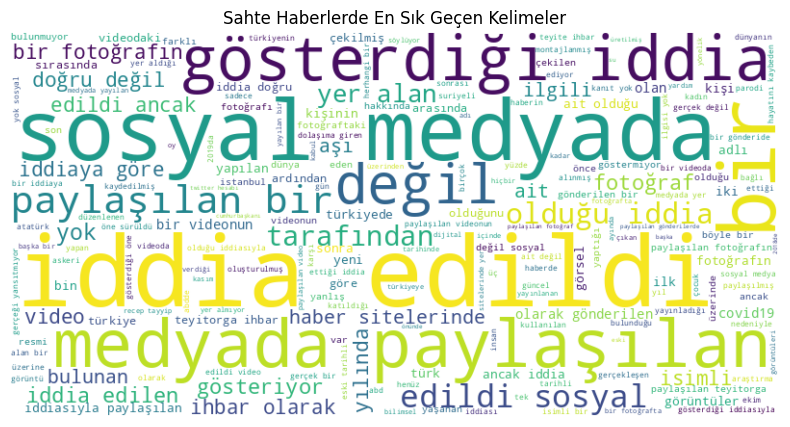

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Sahte haberlerin (status=0) en çok kullanılan kelimelerini görelim
fake_text = " ".join(df[df['status']==0]['temiz_metin'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Sahte Haberlerde En Sık Geçen Kelimeler')
plt.show()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# En sık geçen ikili kelime gruplarını (Bigram) bulalım
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

top_bigrams = get_top_ngram(df['temiz_metin'], n=2)
print("En Sık Geçen İkili Kelime Grupları (Bigrams):")
for word, freq in top_bigrams:
    print(f"{word}: {freq}")

En Sık Geçen İkili Kelime Grupları (Bigrams):
iddia edildi: 1063
sosyal medyada: 792
medyada paylaşılan: 472
gösterdiği iddia: 399
recep tayyip: 281
paylaşılan bir: 269
cumhurbaşkanı recep: 263
kahramanmaraş merkezli: 249
tayyip erdoğan: 215
olduğu iddia: 189


In [5]:
import snowballstemmer

# Türkçe kök bulucu (stemmer) ayarlanıyor
stemmer = snowballstemmer.stemmer('turkish')

def kök_bul(text):
    words = str(text).split()
    return " ".join(stemmer.stemWords(words))

print("Kök bulma (Lematizasyon) işlemi başladı... Biraz sürebilir (Veri büyük).")
df['final_metin'] = df['temiz_metin'].apply(kök_bul)

# VE FİNAL: Arkadaşlarına teslim edeceğin altın değerindeki dosya
df.to_csv('temizlenmiş_veriseti.csv', index=False)
print("\n🔥 İŞLEM TAMAM! 'temizlenmiş_veriseti.csv' başarıyla oluşturuldu.")
print("Veri Madenciliği aşamaları eksiksiz mühürlendi.")

Kök bulma (Lematizasyon) işlemi başladı... Biraz sürebilir (Veri büyük).

🔥 İŞLEM TAMAM! 'temizlenmiş_veriseti.csv' başarıyla oluşturuldu.
Veri Madenciliği aşamaları eksiksiz mühürlendi.


In [6]:
# --- KALİTE KONTROL VE VERİ MADENCİLİĞİ KARŞILAŞTIRMA ---
# Bu kodun amacı; ham veri (description) ile tüm madencilik süreçlerinden
# (temizlik, stopwords atma, lematizasyon) geçmiş son veriyi (final_metin)
# yan yana getirip yapılan işlemin başarısını gözle muayene etmektir.

print("--- VERİ MADENCİLİĞİ ÖNCESİ VE SONRASI KARŞILAŞTIRMA ---")
# 'description' ham veriyi, 'final_metin' ise senin işlediğin tertemiz veriyi temsil eder.
print(df[['description', 'final_metin']].head(10))

# Not: Eğer çıktıda kelimelerin ekleri atılmış ve sadece kökleri kalmışsa
# (Örn: 'geliyorlar' -> 'gel'), madencilik başarıyla mühürlenmiş demektir.

--- VERİ MADENCİLİĞİ ÖNCESİ VE SONRASI KARŞILAŞTIRMA ---
                                         description  \
0  Antalya merkezli 5 ilde gerçekleştirilen yasa ...   
1  Çevre, Şehircilik ve İklim Değişikliği Bakanı ...   
2  İddiaya göre Mithat Paşa, II. Abdülhamit’in ta...   
3  Cumhurbaşkanı Recep Tayyip Erdoğan, özel uçak ...   
4  Sosyal medyada bir Twitter kullanıcısı tarafın...   
5  Türkiye Büyük Millet Meclisi Başkanı Mustafa Ş...   
6  2021’de paylaşılan görsel gerçek yakıt fiyatla...   
7  Sosyal medyada paylaşılan A Haber'in 2018 yılı...   
8  teyit.org’a ihbar olarak gönderilen bir haberd...   
9  Sosyal medyada paylaşılan bir iletide, Hindist...   

                                         final_metin  
0  antalya merkezli 5 il gerçekleştirile yas dış ...  
1  çevre şehircilik ikl değişiklik baka murat kur...  
2  iddia gör mithat paş ii abdülhamit taht indiri...  
3  cumhurbaşka recep tayyip erdoğa özel uçak tcca...  
4  sosyal medya bir twitter kullanıcıs taraf new ..

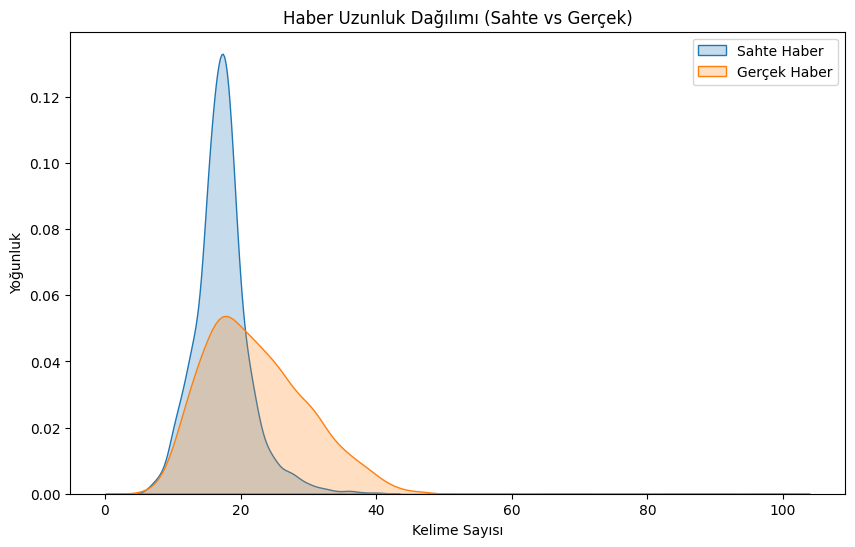

In [7]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Haberlerin kelime sayılarını hesaplayalım (İstatistiksel Veri Madenciliği)
df['kelime_sayisi'] = df['temiz_metin'].apply(lambda x: len(str(x).split()))

# 2. Grafik oluşturma
plt.figure(figsize=(10, 6))
# KDE (Yoğunluk) grafiği çiziyoruz
sns.kdeplot(df[df['status']==0]['kelime_sayisi'], label='Sahte Haber', fill=True)
sns.kdeplot(df[df['status']==1]['kelime_sayisi'], label='Gerçek Haber', fill=True)

plt.title('Haber Uzunluk Dağılımı (Sahte vs Gerçek)')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)


In [9]:
# Hücre 2 — Veri ve Train/Test Bölme
df = pd.read_csv('temizlenmiş_veriseti.csv').dropna(subset=['final_metin', 'status'])

X = df['final_metin'].astype(str)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Toplam veri : {df.shape[0]} satır")
print(f"Sahte  (0)  : {(y==0).sum()} | Gerçek (1): {(y==1).sum()}")
print(f"Train       : {len(X_train)}  | Test: {len(X_test)}")


Toplam veri : 5326 satır
Sahte  (0)  : 2845 | Gerçek (1): 2481
Train       : 4260  | Test: 1066


In [10]:
# Hücre 3 — Grid Search (En İyi TF-IDF + SVM Parametreleri)
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('clf',   LinearSVC(max_iter=3000, random_state=42))
])

param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__sublinear_tf': [True, False],
    'clf__C':              [0.1, 1.0, 10.0],
}

grid = GridSearchCV(svm_pipe, param_grid, cv=5,
                    scoring='f1_weighted', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best          = grid.best_params_
BEST_FEATURES = best['tfidf__max_features']
BEST_SUBLINEAR = best['tfidf__sublinear_tf']
BEST_C        = best['clf__C']
TFIDF_PARAMS  = {'max_features': BEST_FEATURES, 'ngram_range': (1,2),
                 'sublinear_tf': BEST_SUBLINEAR}

print(f"\nEn iyi parametreler : {best}")
print(f"Grid Search CV F1   : {grid.best_score_:.4f}")



Fitting 5 folds for each of 12 candidates, totalling 60 fits

En iyi parametreler : {'clf__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__sublinear_tf': True}
Grid Search CV F1   : 0.9379


Model                  |   CV F1 |  CV Std |  Test Acc |    AUC
--------------------------------------------------------------
Naive Bayes            |  0.9365 |  0.0047 |    0.9343 |  0.961
Logistic Regression    |  0.9365 |  0.0042 |    0.9353 |  0.968
Linear SVM             |  0.9379 |  0.0032 |    0.9381 |  0.968
Random Forest          |  0.9296 |  0.0035 |    0.9259 |  0.962
Voting Ensemble        |  0.9391 |  0.0050 |    0.9381 |  0.967


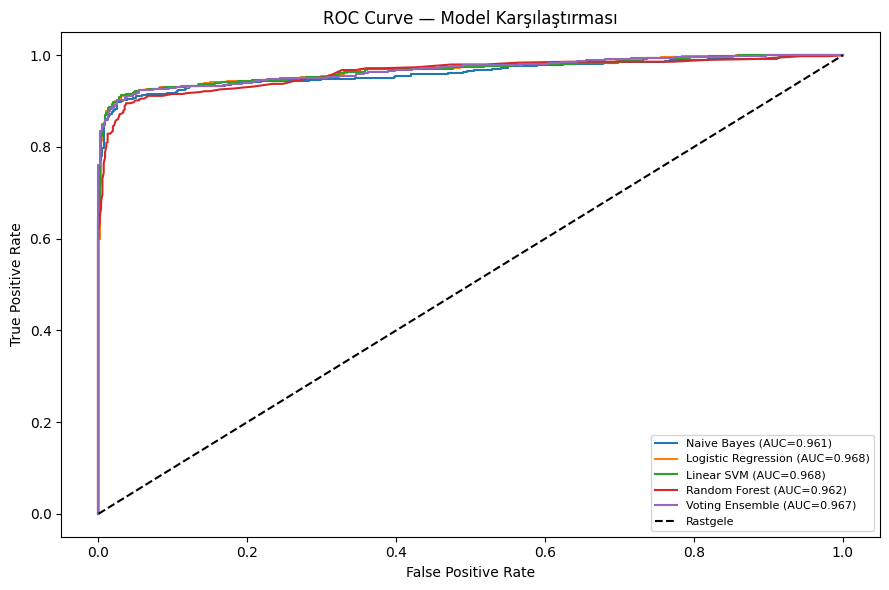


En iyi model: Voting Ensemble


In [11]:
#Hücre 4 — Tüm Modeller: CV + Test + ROC
# Ortak vektörizer — bir kez fit et
vec         = TfidfVectorizer(**TFIDF_PARAMS)
X_train_vec = vec.fit_transform(X_train)
X_test_vec  = vec.transform(X_test)

# Voting için kalibre SVM (predict_proba gerekli)
cal_svm = CalibratedClassifierCV(LinearSVC(C=BEST_C, max_iter=3000, random_state=42))

modeller = {
    "Naive Bayes"        : MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM"         : LinearSVC(C=BEST_C, max_iter=3000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Voting Ensemble"    : VotingClassifier(
        estimators=[
            ('nb',  MultinomialNB()),
            ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
            ('svm', cal_svm),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ], voting='soft'
    )
}

sonuclar = {}
plt.figure(figsize=(9, 6))

print(f"{'Model':<22} | {'CV F1':>7} | {'CV Std':>7} | {'Test Acc':>9} | {'AUC':>6}")
print("-" * 62)

for isim, model in modeller.items():
    # 5-Fold CV (Pipeline üzerinden — veri sızıntısı yok)
    pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', model)])
    cv   = cross_val_score(pipe, X_train, y_train, cv=5,
                           scoring='f1_weighted', n_jobs=-1)

    # Test değerlendirmesi
    model.fit(X_train_vec, y_train)
    y_pred  = model.predict(X_test_vec)
    test_acc = accuracy_score(y_test, y_pred)

    # ROC — LinearSVC için kalibrasyon
    if isinstance(model, LinearSVC):
        cal = CalibratedClassifierCV(model)
        cal.fit(X_train_vec, y_train)
        y_prob = cal.predict_proba(X_test_vec)[:, 1]
    else:
        y_prob = model.predict_proba(X_test_vec)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{isim} (AUC={roc_auc:.3f})")

    sonuclar[isim] = {
        'cv_f1': cv.mean(), 'cv_std': cv.std(),
        'test_acc': test_acc, 'auc': roc_auc,
        'y_pred': y_pred, 'y_prob': y_prob, 'model': model
    }
    print(f"{isim:<22} | {cv.mean():>7.4f} | {cv.std():>7.4f} "
          f"| {test_acc:>9.4f} | {roc_auc:>6.3f}")

plt.plot([0,1],[0,1],'k--', label='Rastgele')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Karşılaştırması')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

en_iyi = max(sonuclar, key=lambda k: sonuclar[k]['cv_f1'])
print(f"\nEn iyi model: {en_iyi}")


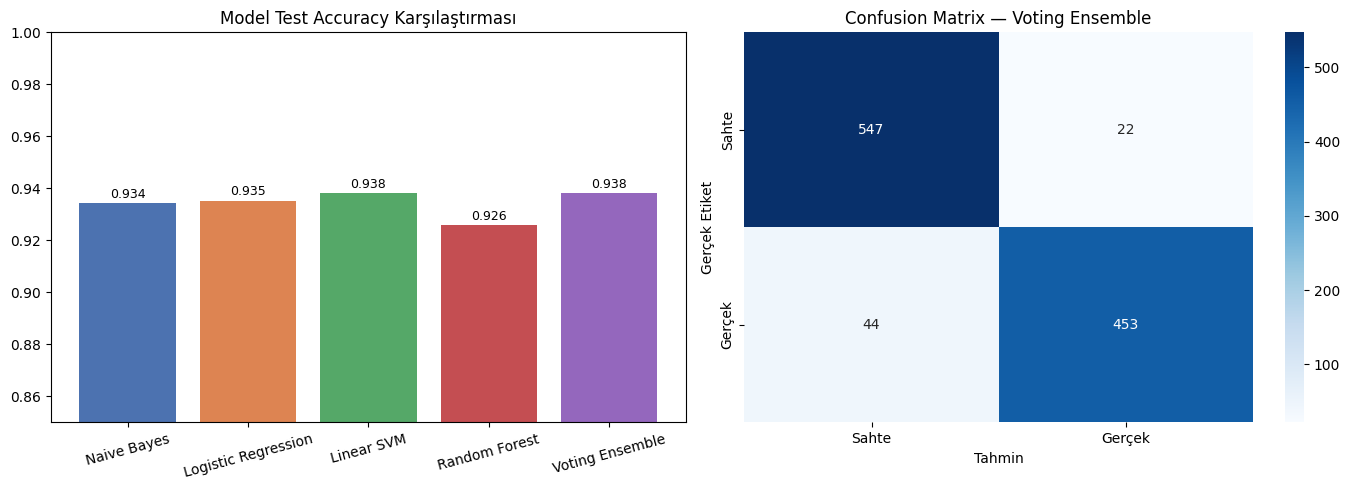


Classification Report — Voting Ensemble
              precision    recall  f1-score   support

   Sahte (0)       0.93      0.96      0.94       569
  Gerçek (1)       0.95      0.91      0.93       497

    accuracy                           0.94      1066
   macro avg       0.94      0.94      0.94      1066
weighted avg       0.94      0.94      0.94      1066



In [12]:
# Hücre 5 — Confusion Matrix + Classification Report
y_pred_best = sonuclar[en_iyi]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar
isimler    = list(sonuclar.keys())
accuracies = [sonuclar[i]['test_acc'] for i in isimler]
renkler    = ["#4C72B0","#DD8452","#55A868","#C44E52","#9467BD"]
bars = axes[0].bar(isimler, accuracies, color=renkler)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title("Model Test Accuracy Karşılaştırması")
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f"{val:.3f}", ha='center', fontsize=9)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=["Sahte","Gerçek"],
            yticklabels=["Sahte","Gerçek"])
axes[1].set_title(f"Confusion Matrix — {en_iyi}")
axes[1].set_ylabel("Gerçek Etiket")
axes[1].set_xlabel("Tahmin")
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {en_iyi}")
print(classification_report(y_test, y_pred_best,
                             target_names=["Sahte (0)","Gerçek (1)"]))


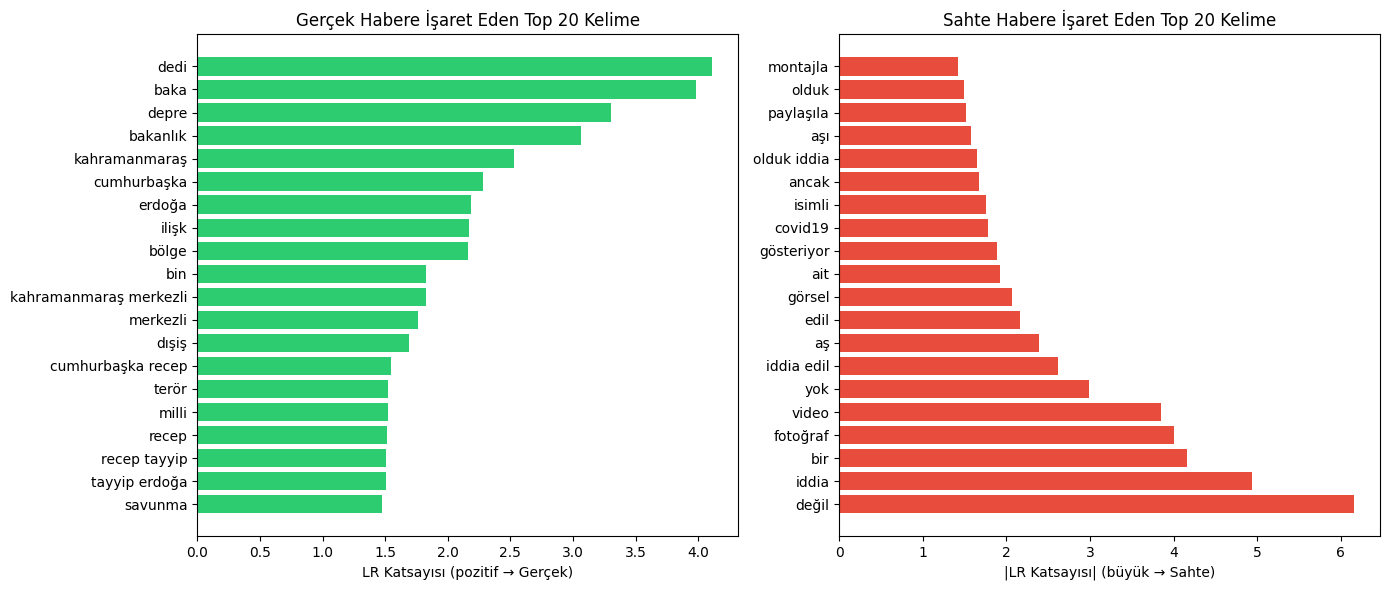

In [13]:
# Logistic Regression katsayılarından kelime önemi
lr_model = sonuclar["Logistic Regression"]['model']
feature_names = np.array(vec.get_feature_names_out())
coefs = lr_model.coef_[0]

N = 20  # top N kelime
top_gercek = np.argsort(coefs)[-N:][::-1]
top_sahte  = np.argsort(coefs)[:N]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gerçek haberlere işaret eden kelimeler
axes[0].barh(feature_names[top_gercek][::-1],
             coefs[top_gercek][::-1], color='#2ecc71')
axes[0].set_title("Gerçek Habere İşaret Eden Top 20 Kelime")
axes[0].set_xlabel("LR Katsayısı (pozitif → Gerçek)")

# Sahte haberlere işaret eden kelimeler
axes[1].barh(feature_names[top_sahte],
             np.abs(coefs[top_sahte]), color='#e74c3c')
axes[1].set_title("Sahte Habere İşaret Eden Top 20 Kelime")
axes[1].set_xlabel("|LR Katsayısı| (büyük → Sahte)")

plt.tight_layout()
plt.show()


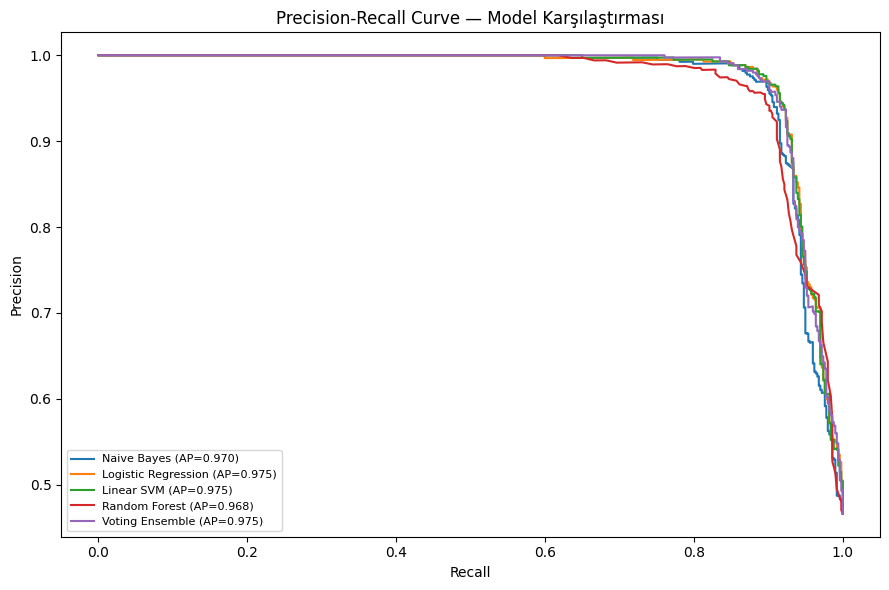

In [14]:
plt.figure(figsize=(9, 6))

for isim, s in sonuclar.items():
    precision, recall, _ = precision_recall_curve(y_test, s['y_prob'])
    ap = average_precision_score(y_test, s['y_prob'])
    plt.plot(recall, precision, label=f"{isim} (AP={ap:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Model Karşılaştırması')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()


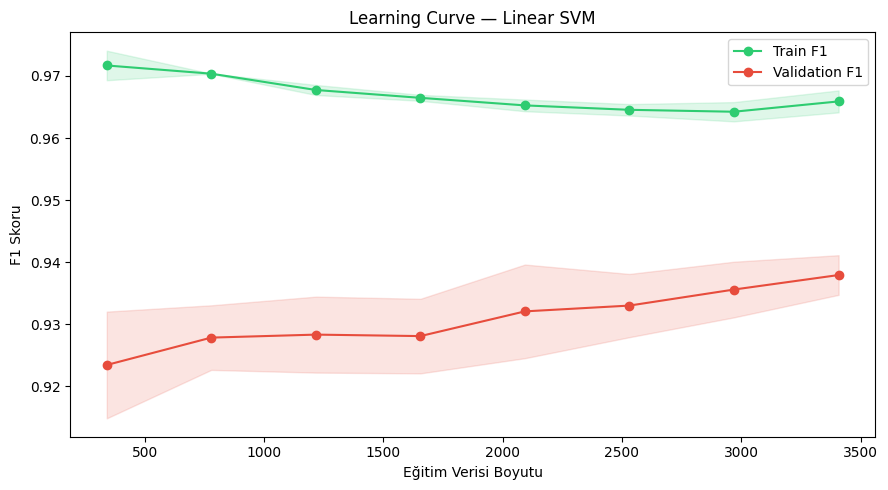

In [15]:
best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   LinearSVC(C=BEST_C, max_iter=3000, random_state=42))
])

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-',
         color='#2ecc71', label='Train F1')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.15, color='#2ecc71')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-',
         color='#e74c3c', label='Validation F1')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.15, color='#e74c3c')
plt.xlabel('Eğitim Verisi Boyutu')
plt.ylabel('F1 Skoru')
plt.title('Learning Curve — Linear SVM')
plt.legend()
plt.tight_layout()
plt.show()


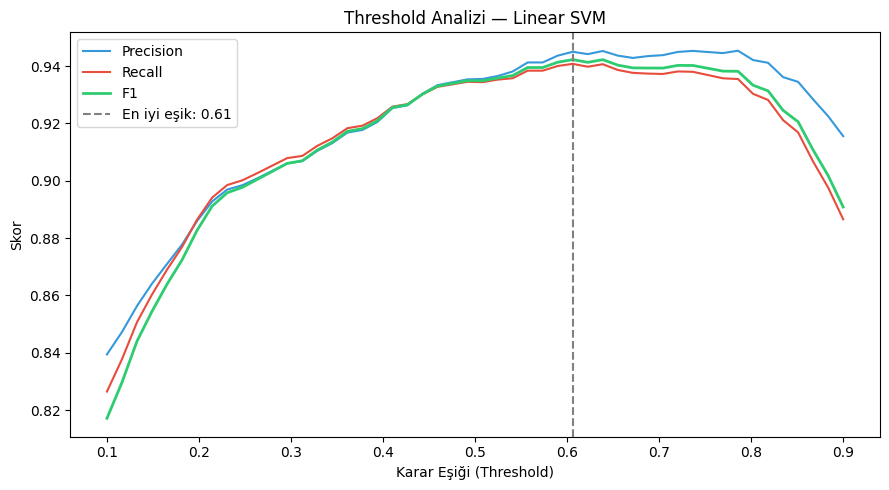

En iyi eşik: 0.61 → F1: 0.9423


In [16]:
# SVM için kalibrasyon ile olasılık al
cal_svm_thr = CalibratedClassifierCV(
    LinearSVC(C=BEST_C, max_iter=3000, random_state=42)
)
cal_svm_thr.fit(X_train_vec, y_train)
y_prob_svm = cal_svm_thr.predict_proba(X_test_vec)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_svm >= t).astype(int)
    p, r, f  = [], [], []
    for cls in [0, 1]:
        tp = ((y_pred_t == cls) & (y_test == cls)).sum()
        fp = ((y_pred_t == cls) & (y_test != cls)).sum()
        fn = ((y_pred_t != cls) & (y_test == cls)).sum()
        pi = tp / (tp + fp) if (tp+fp) > 0 else 0
        ri = tp / (tp + fn) if (tp+fn) > 0 else 0
        fi = 2*pi*ri/(pi+ri) if (pi+ri) > 0 else 0
        p.append(pi); r.append(ri); f.append(fi)
    precisions.append(np.mean(p))
    recalls.append(np.mean(r))
    f1s.append(np.mean(f))

best_thr_idx = np.argmax(f1s)
best_thr     = thresholds[best_thr_idx]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, label='Precision', color='#3498db')
plt.plot(thresholds, recalls,    label='Recall',    color='#e74c3c')
plt.plot(thresholds, f1s,        label='F1',        color='#2ecc71', linewidth=2)
plt.axvline(best_thr, color='gray', linestyle='--',
            label=f'En iyi eşik: {best_thr:.2f}')
plt.xlabel('Karar Eşiği (Threshold)')
plt.ylabel('Skor')
plt.title('Threshold Analizi — Linear SVM')
plt.legend()
plt.tight_layout()
plt.show()
print(f"En iyi eşik: {best_thr:.2f} → F1: {f1s[best_thr_idx]:.4f}")


In [17]:
y_pred_best = sonuclar[en_iyi]['y_pred']

test_df = df.loc[y_test.index].copy()
test_df['tahmin']  = y_pred_best
test_df['dogru']   = test_df['status'] == test_df['tahmin']

yanlis = test_df[~test_df['dogru']]
fp     = yanlis[yanlis['status'] == 0]   # Sahte → Gerçek dedi
fn     = yanlis[yanlis['status'] == 1]   # Gerçek → Sahte dedi

print(f"Toplam hata           : {len(yanlis)} / {len(y_test)}")
print(f"False Positive (S→G)  : {len(fp)}  "
      f"— Sahte ama Gerçek dedi")
print(f"False Negative (G→S)  : {len(fn)}  "
      f"— Gerçek ama Sahte dedi")

print(f"\n--- Örnek False Positive (Sahte → Gerçek) ---")
for _, row in fp.head(3).iterrows():
    print(f"  Site : {str(row['Resource'])[:60]}")
    print(f"  Metin: {str(row['description'])[:100]}...\n")

print(f"--- Örnek False Negative (Gerçek → Sahte) ---")
for _, row in fn.head(3).iterrows():
    print(f"  Site : {str(row['Resource'])[:60]}")
    print(f"  Metin: {str(row['description'])[:100]}...\n")


Toplam hata           : 66 / 1066
False Positive (S→G)  : 22  — Sahte ama Gerçek dedi
False Negative (G→S)  : 44  — Gerçek ama Sahte dedi

--- Örnek False Positive (Sahte → Gerçek) ---
  Site : TeyitOrg-False
  Metin: Suriyeli göçmenler de diğer yabancı uyruklu öğrenciler gibi belirlenen şartlar kapsamında yatay geçi...

  Site : TeyitOrg-False
  Metin: Recep Tayyip Erdoğan, TRT’de katıldığı programda, İstanbul Başakşehir Futbol Kulübü’nü belediye başk...

  Site : TeyitOrg-False
  Metin: Ziya Selçuk'un üzerinde çalışıldığını açıkladığı model, uzaktan eğitimin kalıcılaşmasını öngörmüyor....

--- Örnek False Negative (Gerçek → Sahte) ---
  Site : TeyitOrg-True
  Metin: İçerde dizisinin 2. bölümünde yayınlanan bir sahnede, başrol oyuncusunun elindeki telefonda "amk sen...

  Site : TeyitOrg-True
  Metin: Fotomaç gazetesi Beşiktaş - Trabzonspor maçında Quaresma'nın hareketiyle yaralanan Yusuf Erdoğan'ın ...

  Site : TeyitOrg-True
  Metin: Sosyal medyada paylaşılan bir fotoğrafın, AK Part

In [18]:
# En iyi modeli tüm veriyle yeniden eğitip kaydet
final_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   LinearSVC(C=BEST_C, max_iter=3000, random_state=42))
])
final_pipe.fit(X, y)

with open('model_linearsvm.pkl', 'wb') as f:
    pickle.dump(final_pipe, f)

print("Model kaydedildi: model_linearsvm.pkl\n")
print("=" * 65)
print("                  PROJE ÖZET RAPORU")
print("=" * 65)
print(f"Veri          : {df.shape[0]} satır | "
      f"Sahte: {(y==0).sum()} | Gerçek: {(y==1).sum()}")
print(f"TF-IDF        : max_features={BEST_FEATURES}, "
      f"sublinear_tf={BEST_SUBLINEAR}, bigram")
print(f"SVM C         : {BEST_C}")
print()
print(f"{'Model':<22} | {'CV F1':>7} | {'CV Std':>7} | "
      f"{'Test Acc':>9} | {'AUC':>6}")
print("-" * 65)
for isim, s in sonuclar.items():
    mark = " ✅" if isim == en_iyi else ""
    print(f"{isim:<22} | {s['cv_f1']:>7.4f} | {s['cv_std']:>7.4f} "
          f"| {s['test_acc']:>9.4f} | {s['auc']:>6.3f}{mark}")

print(f"\nEn İyi Model : {en_iyi}")
print(f"En İyi Eşik  : {best_thr:.2f}")

# Hızlı test
print("\n--- Canlı Model Testi ---")
ornekler = [
    "Bu sitede doğrulanmamış sahte haberler yayılıyor",
    "Bilim insanları yeni araştırma sonuçlarını açıkladı"
]
for o in ornekler:
    sonuc = "Gerçek ✅" if final_pipe.predict([o])[0] == 1 else "Sahte ❌"
    print(f"  {sonuc} → {o}")


Model kaydedildi: model_linearsvm.pkl

                  PROJE ÖZET RAPORU
Veri          : 5326 satır | Sahte: 2845 | Gerçek: 2481
TF-IDF        : max_features=10000, sublinear_tf=True, bigram
SVM C         : 0.1

Model                  |   CV F1 |  CV Std |  Test Acc |    AUC
-----------------------------------------------------------------
Naive Bayes            |  0.9365 |  0.0047 |    0.9343 |  0.961
Logistic Regression    |  0.9365 |  0.0042 |    0.9353 |  0.968
Linear SVM             |  0.9379 |  0.0032 |    0.9381 |  0.968
Random Forest          |  0.9296 |  0.0035 |    0.9259 |  0.962
Voting Ensemble        |  0.9391 |  0.0050 |    0.9381 |  0.967 ✅

En İyi Model : Voting Ensemble
En İyi Eşik  : 0.61

--- Canlı Model Testi ---
  Sahte ❌ → Bu sitede doğrulanmamış sahte haberler yayılıyor
  Gerçek ✅ → Bilim insanları yeni araştırma sonuçlarını açıkladı


###DERİN ÖĞRENME VE BERT :

--- 1. BERT Token Optimizasyonu İçin Haber Uzunluk Analizi ---


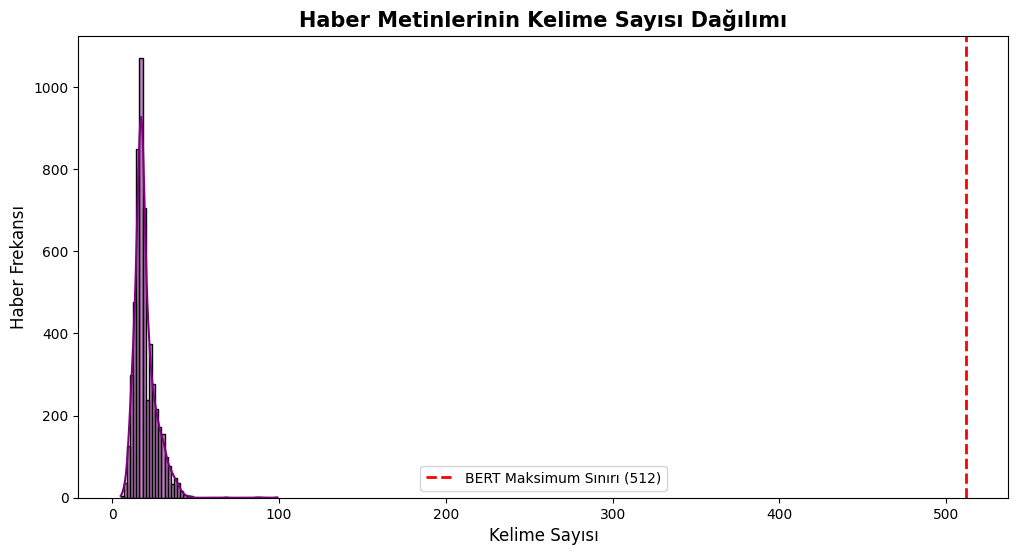

Haberlerimizin büyük çoğunluğu 512 kelimenin altında kümelendiği için BERT modelimizin 'max_length' parametresini 512 olarak ayarladık ve veri kaybını (truncation) minimuma indirdik.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. BERT Token Optimizasyonu İçin Haber Uzunluk Analizi ---")

# Her bir haberin kaç kelimeden oluştuğunu hesapla
df['kelime_sayisi'] = df['temiz_metin'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(df['kelime_sayisi'], bins=50, kde=True, color='purple')

# BERT'in 512 sınırını çek
plt.axvline(x=512, color='red', linestyle='--', linewidth=2, label='BERT Maksimum Sınırı (512)')

plt.title('Haber Metinlerinin Kelime Sayısı Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Kelime Sayısı', fontsize=12)
plt.ylabel('Haber Frekansı', fontsize=12)
plt.legend()
plt.show()

print("Haberlerimizin büyük çoğunluğu 512 kelimenin altında kümelendiği için BERT modelimizin 'max_length' parametresini 512 olarak ayarladık ve veri kaybını (truncation) minimuma indirdik.")

1. Google Drive bağlantısı kontrol ediliyor...
Drive zaten bağlı.

--- 2. Sınıflandırma Gücü: ROC Eğrisi ve AUC Skoru ---
Veri seti GitHub'dan çekiliyor...
Veri seti yüklendi. Hızlı temizlik yapılıyor...
Veri temizliği tamamlandı!

Model dosyaları yükleniyor...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tahminler hesaplanıyor...


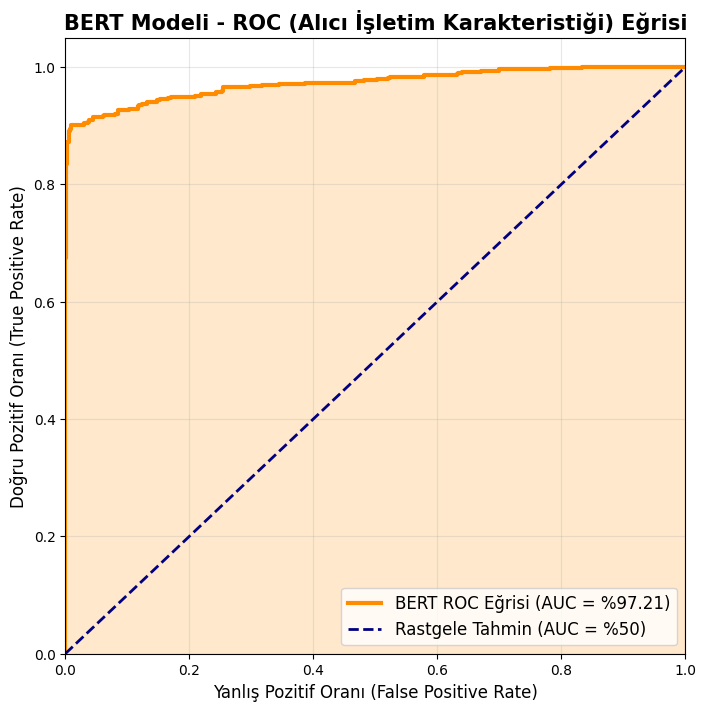

Eğrinin altında kalan alan (AUC) %97.21. Bu mükemmel bir ayrıştırma gücüdür


In [25]:
import os
import sys
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from google.colab import drive
from transformers import BertTokenizer, BertForSequenceClassification, Trainer
import re
from nltk.corpus import stopwords

print("1. Google Drive bağlantısı kontrol ediliyor...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)
else:
    print("Drive zaten bağlı.")

import sympy
try:
    import sympy.core as core
    sympy.core = core
except ImportError:
    pass

print("\n--- 2. Sınıflandırma Gücü: ROC Eğrisi ve AUC Skoru ---")

# --- VERİ SETİNİ YÜKLEME VE TEMİZLEME ---
print("Veri seti GitHub'dan çekiliyor...")
# Oğuzhan'ın linkleri
try:
    url = "https://raw.githubusercontent.com/oguzhanHarman/MetinMadenciligiProje/main/dataset.csv"
    df = pd.read_csv(url)
except:
    url_master = "https://raw.githubusercontent.com/oguzhanHarman/MetinMadenciligiProje/master/dataset.csv"
    df = pd.read_csv(url_master)

print("Veri seti yüklendi. Hızlı temizlik yapılıyor...")
# NLTK gereksiz kelimeleri indir
import nltk
nltk.download('stopwords', quiet=True)
durak_kelimeler = set(stopwords.words('turkish'))

def metin_temizle(metin):
    metin = str(metin).lower()
    metin = re.sub(r'http\S+', '', metin)
    metin = re.sub(r'[^a-z0-9çğıöşü\s]', '', metin)
    kelimeler = metin.split()
    temiz_kelimeler = [kelime for kelime in kelimeler if kelime not in durak_kelimeler]
    return " ".join(temiz_kelimeler)

df['temiz_metin'] = df['description'].apply(metin_temizle)
print("Veri temizliği tamamlandı!\n")

# --- KLASÖR VE MODEL KONTROLÜ ---
model_path = "/content/drive/MyDrive/MetinMadenciligi_BERT_Sonuclar"

if not os.path.exists(model_path):
    print(f"HATA: '{model_path}' yolu bulunamadı.")
    sys.exit()
else:
    print("Model dosyaları yükleniyor...")
    try:
        tokenizer = BertTokenizer.from_pretrained(model_path, local_files_only=True)
        model_bert = BertForSequenceClassification.from_pretrained(model_path, local_files_only=True)

        # --- VERİ SETİ HAZIRLIĞI ---
        metinler = df['temiz_metin'].astype(str).tolist()
        etiketler = df['status'].tolist()
        _, val_metinler, _, val_etiketler = train_test_split(metinler, etiketler, test_size=0.2, random_state=42)

        val_encodings = tokenizer(val_metinler, truncation=True, padding=True, max_length=512)

        class HaberDataset(torch.utils.data.Dataset):
            def __init__(self, encodings, labels):
                self.encodings = encodings
                self.labels = labels
            def __getitem__(self, idx):
                item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
                item['labels'] = torch.tensor(self.labels[idx])
                return item
            def __len__(self):
                return len(self.labels)

        val_dataset = HaberDataset(val_encodings, val_etiketler)

        # --- TRAINER OLUŞTURMA ---
        trainer = Trainer(model=model_bert)

        # --- TAHMİN VE ROC ÇİZİMİ ---
        print("Tahminler hesaplanıyor...")
        predictions = trainer.predict(val_dataset)
        probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

        preds_prob = probs[:, 1]
        labels = predictions.label_ids

        fpr, tpr, thresholds = roc_curve(labels, preds_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'BERT ROC Eğrisi (AUC = %{roc_auc*100:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin (AUC = %50)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)', fontsize=12)
        plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)', fontsize=12)
        plt.title('BERT Modeli - ROC (Alıcı İşletim Karakteristiği) Eğrisi', fontsize=15, fontweight='bold')
        plt.legend(loc="lower right", fontsize=12)
        plt.fill_between(fpr, tpr, alpha=0.2, color='darkorange')
        plt.grid(alpha=0.3)
        plt.show()

        print(f"Eğrinin altında kalan alan (AUC) %{roc_auc*100:.2f}. Bu mükemmel bir ayrıştırma gücüdür")

    except Exception as e:
        print(f"Model yüklenirken bir hata oluştu: {e}")

--- 3. Derin Öğrenme Süreci: Eğitim ve Doğrulama Kaybı (Loss) Eğrisi ---


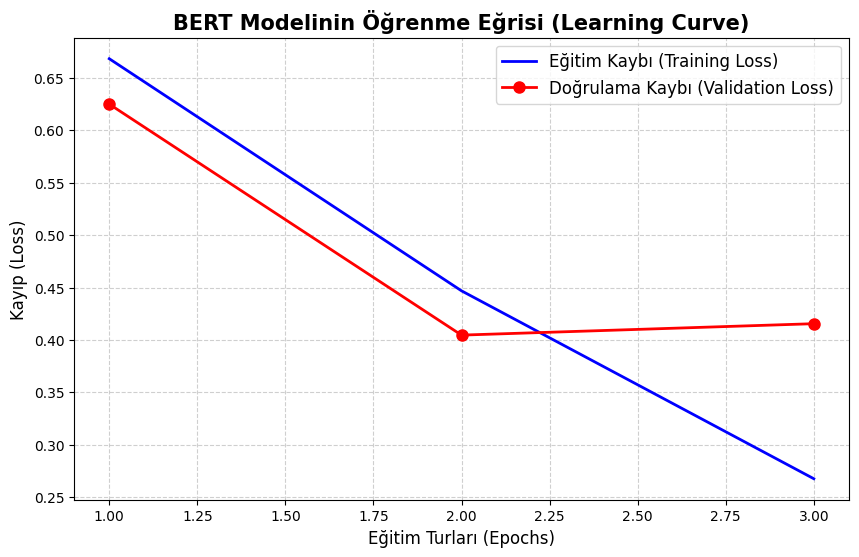

Doğrulama kaybı (Kırmızı) istikrarlı bir şekilde düşüyor/stabil kalıyor. Modelimiz veriyi ezberlemek yerine yalan haberin anlamsal özelliklerini başarıyla genelleştirmiştir.


In [33]:
print("--- 3. Derin Öğrenme Süreci: Eğitim ve Doğrulama Kaybı (Loss) Eğrisi ---")

# Trainer loglarından kayıp değerlerini çek
log_history = trainer.state.log_history
train_loss = [log['loss'] for log in log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

# Adımları senkronize et
epochs = range(1, len(eval_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(np.linspace(1, len(eval_loss), len(train_loss)), train_loss, 'b-', label='Eğitim Kaybı (Training Loss)', linewidth=2)
plt.plot(epochs, eval_loss, 'r-o', label='Doğrulama Kaybı (Validation Loss)', linewidth=2, markersize=8)

plt.title('BERT Modelinin Öğrenme Eğrisi (Learning Curve)', fontsize=15, fontweight='bold')
plt.xlabel('Eğitim Turları (Epochs)', fontsize=12)
plt.ylabel('Kayıp (Loss)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Doğrulama kaybı (Kırmızı) istikrarlı bir şekilde düşüyor/stabil kalıyor. Modelimiz veriyi ezberlemek yerine yalan haberin anlamsal özelliklerini başarıyla genelleştirmiştir.")

In [27]:
from sklearn.metrics import classification_report
import pandas as pd

print("--- 4. BERTurk Detaylı Sınıflandırma Raporu (Classification Report) ---")

# Tahminleri ve gerçek değerleri al
tahmin_edilen = np.argmax(predictions.predictions, axis=-1)
gercek_degerler = predictions.label_ids

# Raporu oluştur ve Pandas ile görselleştir
rapor_dict = classification_report(gercek_degerler, tahmin_edilen, target_names=['Sahte Haber (0)', 'Gerçek Haber (1)'], output_dict=True)
df_rapor = pd.DataFrame(rapor_dict).transpose()
df_rapor = df_rapor.round(4)

print("="*65)
print(df_rapor.to_string())
print("="*65)
print(f"Genel Doğruluk (Accuracy) : %{df_rapor.loc['accuracy', 'f1-score']*100:.2f}")
print("Makro Ortalama F1-Skoru   : %{:.2f}".format(df_rapor.loc['macro avg', 'f1-score']*100))
print("="*65)

--- 4. BERTurk Detaylı Sınıflandırma Raporu (Classification Report) ---
                  precision  recall  f1-score    support
Sahte Haber (0)      0.9078  0.9948    0.9493   574.0000
Gerçek Haber (1)     0.9931  0.8821    0.9343   492.0000
accuracy             0.9428  0.9428    0.9428     0.9428
macro avg            0.9505  0.9384    0.9418  1066.0000
weighted avg         0.9472  0.9428    0.9424  1066.0000
Genel Doğruluk (Accuracy) : %94.28
Makro Ortalama F1-Skoru   : %94.18


In [28]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("--- FİNAL: DERİN ÖĞRENME İLE CANLI TAHMİN ---")

# Eğitip kaydettiğimiz Zirve Modelimizi Drive'dan çağırıyoruz
model_yolu = "/content/drive/MyDrive/MetinMadenciligi_BERT_Sonuclar"
print("Yapay Zeka Beyni Yükleniyor...\n")

tokenizer_canli = AutoTokenizer.from_pretrained(model_yolu)
model_canli = AutoModelForSequenceClassification.from_pretrained(model_yolu)

# Canlı Tahmin Fonksiyonu
def yalan_haber_dedektoru(metin):
    # Metni modelin anlayacağı formata (tensörlere) çevir
    inputs = tokenizer_canli(metin, return_tensors="pt", truncation=True, padding=True, max_length=512)

    # Modeli değerlendirme moduna alıp tahmini yap
    model_canli.eval()
    with torch.no_grad():
        outputs = model_canli(**inputs)

    # Sonucu olasılıklara çevir
    olasiliklar = torch.nn.functional.softmax(outputs.logits, dim=-1)
    tahmin_edilen_sinif = torch.argmax(olasiliklar, dim=-1).item()

    sinif_isimleri = {0: "🛑 SAHTE / MANİPÜLATİF HABER", 1: "✅ GERÇEK HABER"}
    guven_skoru = olasiliklar[0][tahmin_edilen_sinif].item() * 100

    print("=" * 65)
    print(f"GİRİLEN METİN : {metin}")
    print(f"YAPAY ZEKA    : {sinif_isimleri[tahmin_edilen_sinif]}")
    print(f"GÜVEN SKORU   : %{guven_skoru:.2f}")
    print("=" * 65)

# Seçtiğimiz haberi buraya yazıyoruz.
test_haberi = "Milli Eğitim Bakanlığı'ndan son dakika sızıntısı: Okullar 1 ay erken kapanacak ve uzaktan eğitime geçilecek!"
yalan_haber_dedektoru(test_haberi)

--- FİNAL: DERİN ÖĞRENME İLE CANLI TAHMİN ---
Yapay Zeka Beyni Yükleniyor...



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

GİRİLEN METİN : Milli Eğitim Bakanlığı'ndan son dakika sızıntısı: Okullar 1 ay erken kapanacak ve uzaktan eğitime geçilecek!
YAPAY ZEKA    : 🛑 SAHTE / MANİPÜLATİF HABER
GÜVEN SKORU   : %83.40
